In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/cleaned/playstore_features.csv")
print(df.shape)   # expect (9658, 22)

(9658, 22)


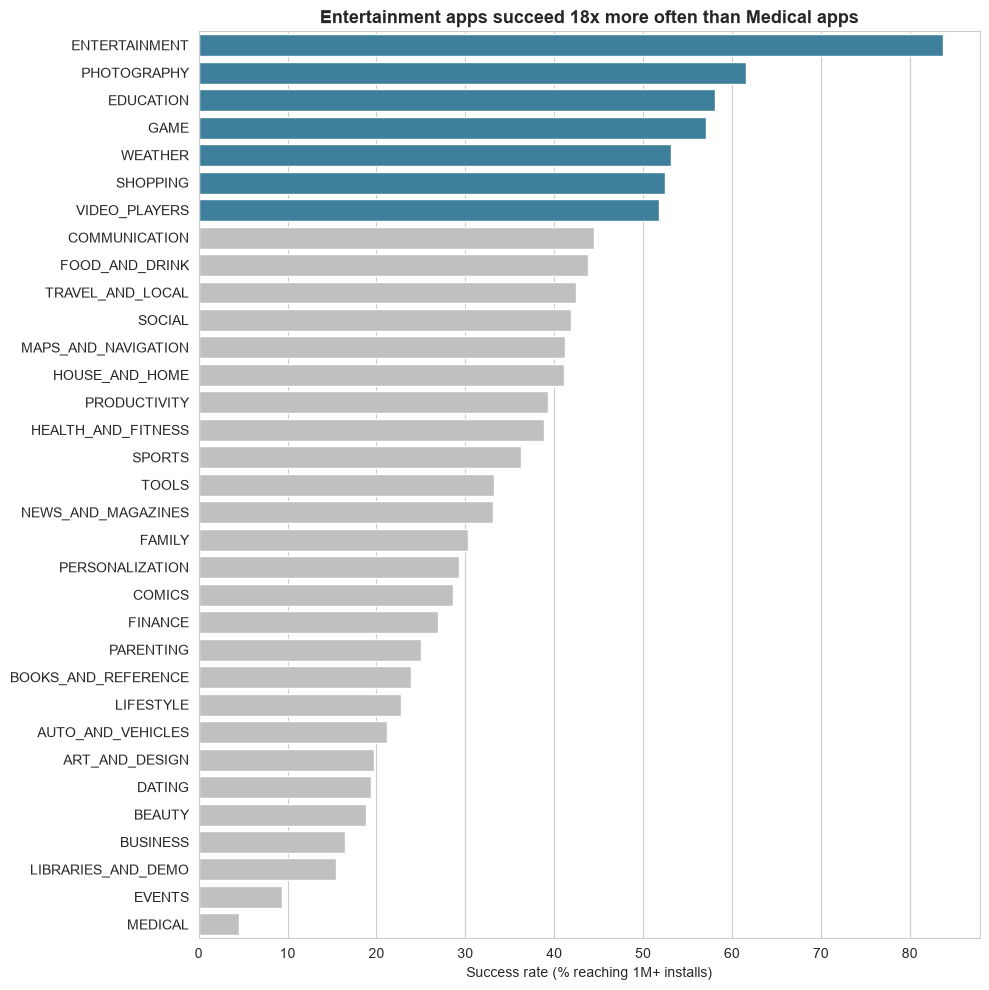

In [3]:
cat_stats = (df.groupby("Category")
             .filter(lambda x: len(x) >= 50)
             .groupby("Category")["Success"]
             .agg(["count", "mean"])
             .rename(columns={"count": "n_apps", "mean": "success_rate"})
             .sort_values("success_rate", ascending=False))
cat_stats["success_rate"] *= 100

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["#2E86AB" if x >= 50 else "#C0C0C0" for x in cat_stats["success_rate"]]
sns.barplot(x=cat_stats["success_rate"], y=cat_stats.index, hue=cat_stats.index,
            palette=colors, legend=False, ax=ax)
ax.set_title("Entertainment apps succeed 18x more often than Medical apps",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Success rate (% reaching 1M+ installs)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../images/01_success_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

Takeaway: "Success rates vary 18x across categories — Entertainment, Photography, and Education are the easiest to succeed in, while Medical, Events, and Libraries are the hardest."

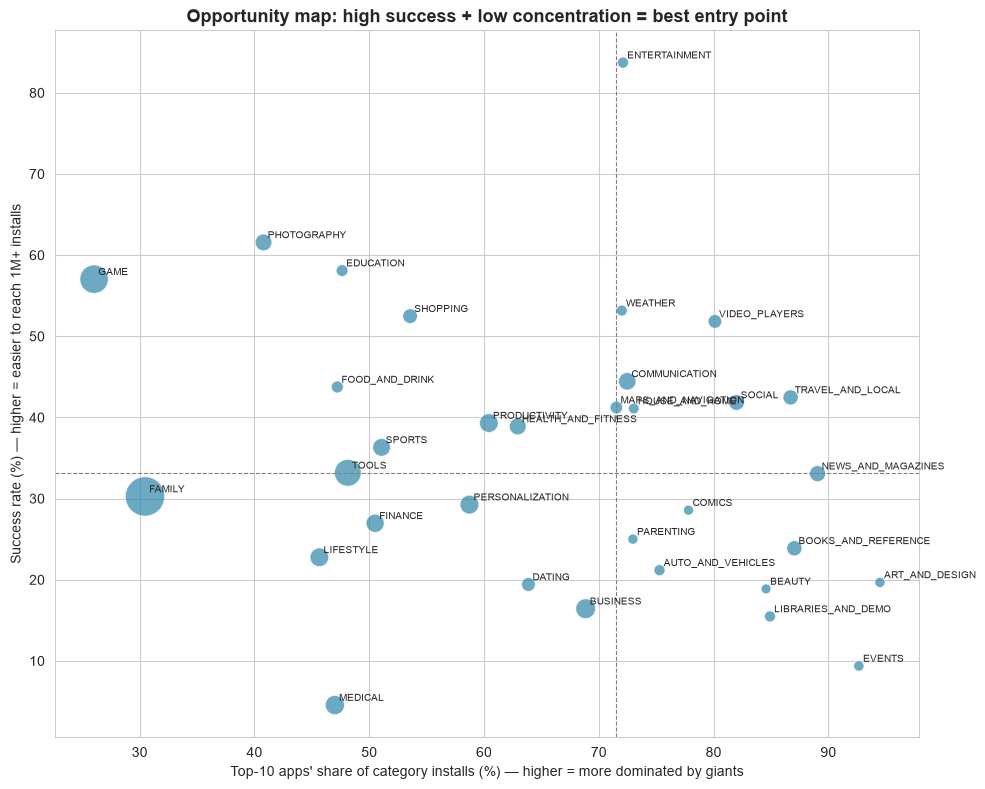

In [4]:
# Rebuild the concentration numbers from Step 4's SQL logic, in pandas
def top10_share(group):
    total = group["Installs"].sum()
    top10 = group.nlargest(10, "Installs")["Installs"].sum()
    return 100 * top10 / total

conc = (df.groupby("Category")
        .filter(lambda x: len(x) >= 50)
        .groupby("Category")
        .apply(top10_share)
        .rename("top10_share"))

quad = cat_stats.join(conc)

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=quad, x="top10_share", y="success_rate", size="n_apps",
                 sizes=(50, 800), legend=False, ax=ax, color="#2E86AB", alpha=0.7)

for cat in quad.index:
    ax.annotate(cat, (quad.loc[cat, "top10_share"], quad.loc[cat, "success_rate"]),
                fontsize=7, xytext=(3, 3), textcoords="offset points")

ax.axhline(quad["success_rate"].median(), color="gray", linestyle="--", linewidth=0.8)
ax.axvline(quad["top10_share"].median(), color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Opportunity map: high success + low concentration = best entry point",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Top-10 apps' share of category installs (%) — higher = more dominated by giants")
ax.set_ylabel("Success rate (%) — higher = easier to reach 1M+ installs")
plt.tight_layout()
plt.savefig("../images/02_opportunity_quadrant.png", dpi=150, bbox_inches="tight")
plt.show()

Takeaway: "Entertainment offers the best balance of high success (83.7%) without extreme market concentration. Game and Family attract the most apps but deliver the lowest returns — classic overcrowded, low-reward categories."

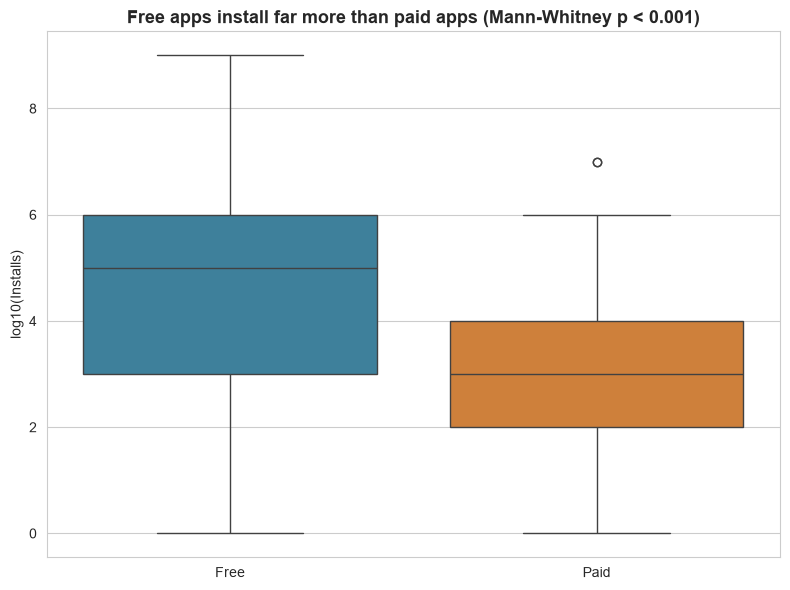

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_df = df.copy()
plot_df["Installs_log"] = np.log10(plot_df["Installs"] + 1)

sns.boxplot(data=plot_df, x="Type", y="Installs_log", hue="Type",
            palette=["#2E86AB", "#E67E22"], legend=False, ax=ax)
ax.set_title("Free apps install far more than paid apps (Mann-Whitney p < 0.001)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("log10(Installs)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../images/03_free_vs_paid.png", dpi=150, bbox_inches="tight")
plt.show()

Takeaway: "Free apps install at roughly 100x the rate of paid apps at the median — pricing is one of the strongest levers a new app has."

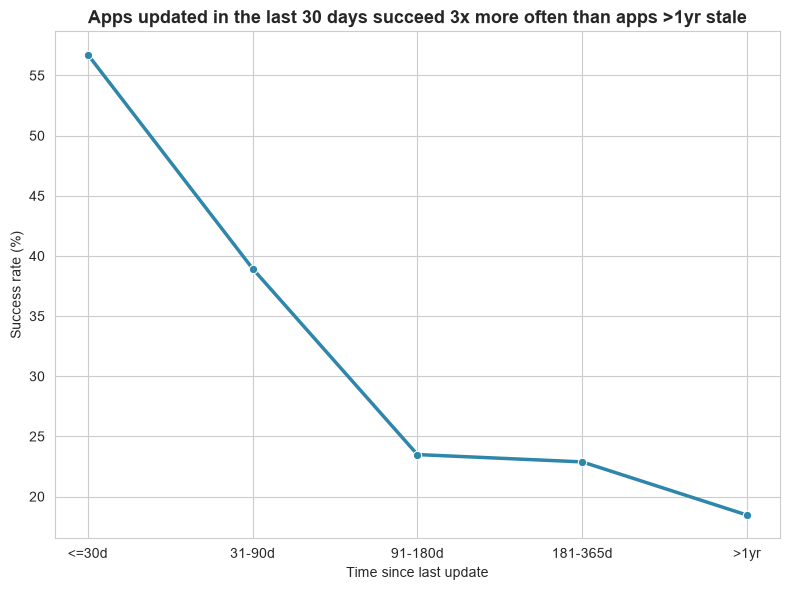

In [7]:
order = ["<=30d", "31-90d", "91-180d", "181-365d", ">1yr"]
update_stats = df.groupby("Update_Bucket", observed=True)["Success"].mean().reindex(order) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(x=order, y=update_stats.values, marker="o", linewidth=2.5,
             color="#2E86AB", ax=ax)
ax.set_title("Apps updated in the last 30 days succeed 3x more often than apps >1yr stale",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time since last update")
ax.set_ylabel("Success rate (%)")
plt.tight_layout()
plt.savefig("../images/04_update_recency.png", dpi=150, bbox_inches="tight")
plt.show()

Takeaway: "Success rate drops sharply after 90 days without an update — apps updated in the last 30 days succeed 3x more often than apps untouched for over a year."

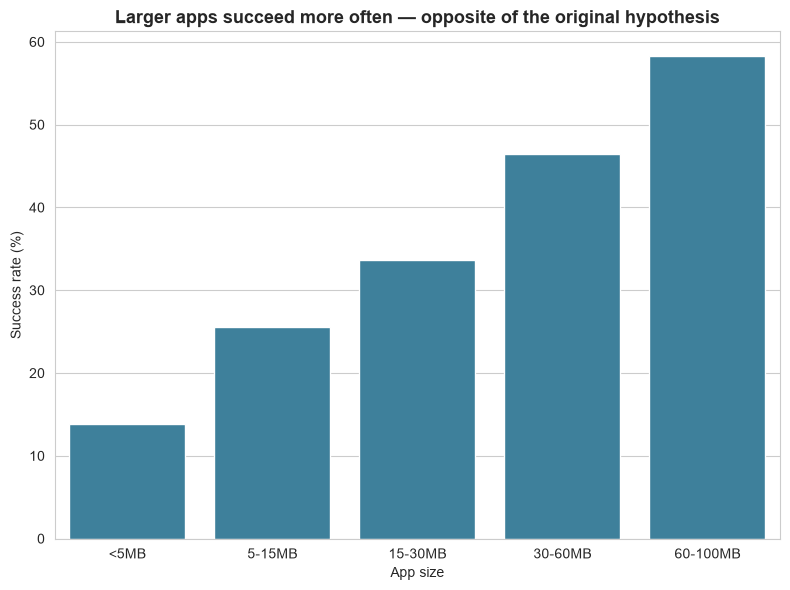

In [8]:
order = ["<5MB", "5-15MB", "15-30MB", "30-60MB", "60-100MB"]
size_stats = df.groupby("Size_Bucket", observed=True)["Success"].mean().reindex(order) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=order, y=size_stats.values, color="#2E86AB", ax=ax)
ax.set_title("Larger apps succeed more often — opposite of the original hypothesis",
             fontsize=13, fontweight="bold")
ax.set_xlabel("App size")
ax.set_ylabel("Success rate (%)")
plt.tight_layout()
plt.savefig("../images/05_size_vs_success.png", dpi=150, bbox_inches="tight")
plt.show()

Takeaway: "Contrary to the initial hypothesis, larger apps succeed more often — 58.3% for 60-100MB apps vs 13.8% for apps under 5MB, likely because feature-rich categories like games and media happen to be both larger and more popular."

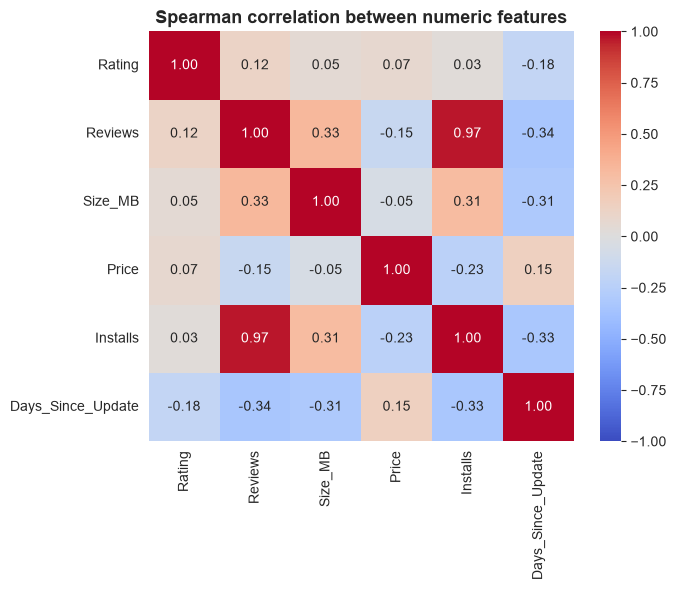

In [9]:
num_cols = ["Rating", "Reviews", "Size_MB", "Price", "Installs", "Days_Since_Update"]
corr = df[num_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            vmin=-1, vmax=1)
ax.set_title("Spearman correlation between numeric features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/06_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Takeaway: "Reviews and Installs are almost perfectly correlated (ρ = 0.97) — confirming Reviews is an outcome of app success, not a usable predictor. Size and update recency show moderate, more actionable correlations with Installs (ρ = 0.31 and -0.33 respectively)."

**Takeaway:** Entertainment, Photography, and Education have the highest success rates,
while Medical and Game are the hardest categories to succeed in despite Game having
the most apps.